After asking around for the source of the existing data, you learn that the current process is to take a monthly snapshot of prices from a market data provider, which represents the market price of natural gas delivered at the end of each calendar month. This data is available for roughly the next 18 months and is combined with historical prices in a time series database. After gaining access, you are able to download the data in a CSV file.

You should use this monthly snapshot to produce a varying picture of the existing price data, as well as an extrapolation for an extra year, in case the client needs an indicative price for a longer-term storage contract.

Download the monthly natural gas price data.
Each point in the data set corresponds to the purchase price of natural gas at the end of a month, from 31st October 2020 to 30th September 2024.
Analyze the data to estimate the purchase price of gas at any date in the past and extrapolate it for one year into the future. 
Your code should take a date as input and return a price estimate.
Try to visualize the data to find patterns and consider what factors might cause the price of natural gas to vary. This can include looking at months of the year for seasonal trends that affect the prices, but market holidays, weekends, and bank holidays need not be accounted for. Submit your completed code below.

Note: This role often requires the knowledge and utilization of data analysis and machine learning. Python is a useful tool and one that JPMorgan Chase uses a lot in quantitative research since it’s capable of completing complex tasks.

Moving forward in this program, the example answers are given in Python code. (If Python is not downloaded on your system, you can execute Python code in Jupyter Notebook online for free.)



## Load the Dataset

In [2]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv(r'Nat_Gas.csv')
df.head()

,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Dates   48 non-null     str    
 1   Prices  48 non-null     float64
dtypes: float64(1), str(1)
memory usage: 900.0 bytes


# Convert Date Column

In [14]:
df['Dates'] = pd.to_datetime(df['Dates'])

C:\Users\rajpu\AppData\Local\Temp\ipykernel_8432\2452315616.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Dates   48 non-null     datetime64[us]
 1   Prices  48 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 900.0 bytes


# Rename Columns

In [16]:
df.columns = ['Date', 'Price']
df.head()

,Date,Price
0,2020-10-31,10.1
1,2020-11-30,10.3
2,2020-12-31,11.0
3,2021-01-31,10.9
4,2021-02-28,10.9


In [8]:
df.describe()

,Prices
count,48.000000
mean,11.207083
std,0.757897
min,9.840000
25%,10.650000
50%,11.300000
75%,11.625000
max,12.800000


In [9]:
df.isnull().sum()

Dates     0
Prices    0
dtype: int64

As we see our data is clearn o no need to perform EDA but e use visulization to se the trends and gain some more informnation

# Visualize Historical Natural Gas Prices

In [17]:
import matplotlib.pyplot as plt

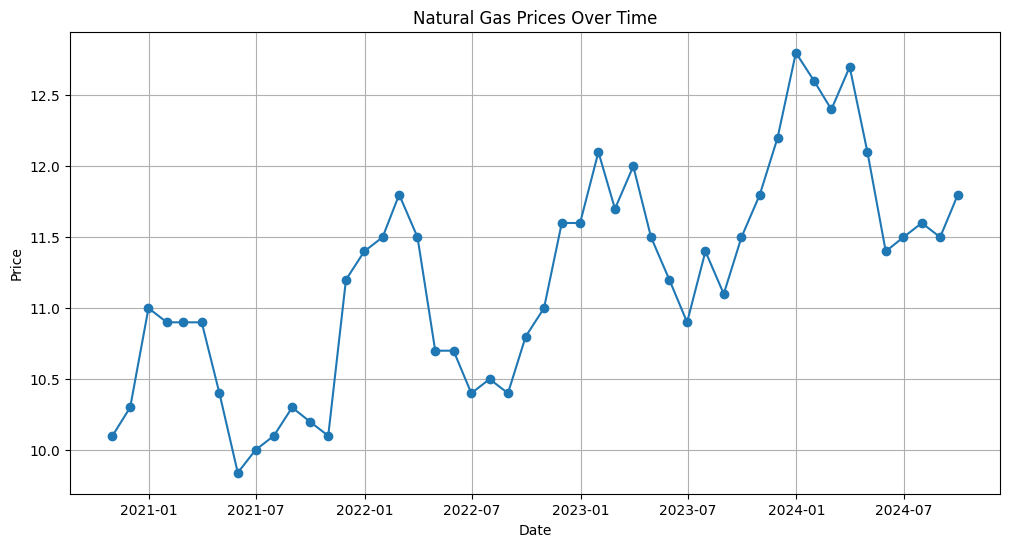

In [18]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Price'], marker='o')
plt.title('Natural Gas Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

## Observations from Visualization

After plotting the data, several important patterns can be observed:

### 1. Seasonality

Natural gas prices show strong seasonal behavior.

- Prices usually increase during winter months.
- Winter demand rises because gas is heavily used for heating.
- Prices often decline during warmer months.

### 2. Trend

There is an overall upward trend in prices over time.

Possible reasons:

- Increasing energy demand
- Supply chain disruptions
- Geopolitical events
- Inflation and transportation costs

### 3. Cyclical Fluctuations

The market experiences recurring price cycles influenced by:

- Weather conditions
- Storage levels
- Economic activity
- Production rates

# Create a Time Series Model

To forecast future prices, we use:

#### Holt-Winters Exponential Smoothing

This model is suitable because:

- The data contains trend.
- The data contains seasonality.
- Monthly gas prices often repeat seasonal patterns.

# Fit Forecasting Model

In [20]:
! pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 3.3 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.5 MB 3.4 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.5 MB 3.4 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.5 MB 3.3 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.5 MB 3.4 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.5 MB 3.4 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.5 MB 3.7 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.5 MB 3.8 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.5 MB 3.8 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.5 MB 3.8 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.5 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 3.8 MB/s eta 0:00:01
   ----------------


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [23]:
series = df.set_index('Date')['Price']

model = ExponentialSmoothing(
    series,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

future_forecast = model.forecast(12)


future_dates = pd.date_range(
    start=series.index[-1] + pd.offsets.MonthEnd(1),
    periods=12,
    freq='ME'
)


forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast_Price': future_forecast.values
})

print(forecast_df)

c:\Users\rajpu\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


         Date  Forecast_Price
0  2024-10-31       12.103735
1  2024-11-30       12.678726
2  2024-12-31       13.053696
3  2025-01-31       13.128708
4  2025-02-28       13.053707
5  2025-03-31       13.128723
6  2025-04-30       12.528721
7  2025-05-31       12.138744
8  2025-06-30       12.053741
9  2025-07-31       12.253755
10 2025-08-31       12.178762
11 2025-09-30       12.428762


# Combine Historical and Forecast Data

In [24]:
future_df = pd.DataFrame({
    'Date': future_dates,
    'Price': future_forecast.values
})

combined_df = pd.concat([
    df[['Date', 'Price']],
    future_df
], ignore_index=True)

# Visualize Historical + Forecast Prices

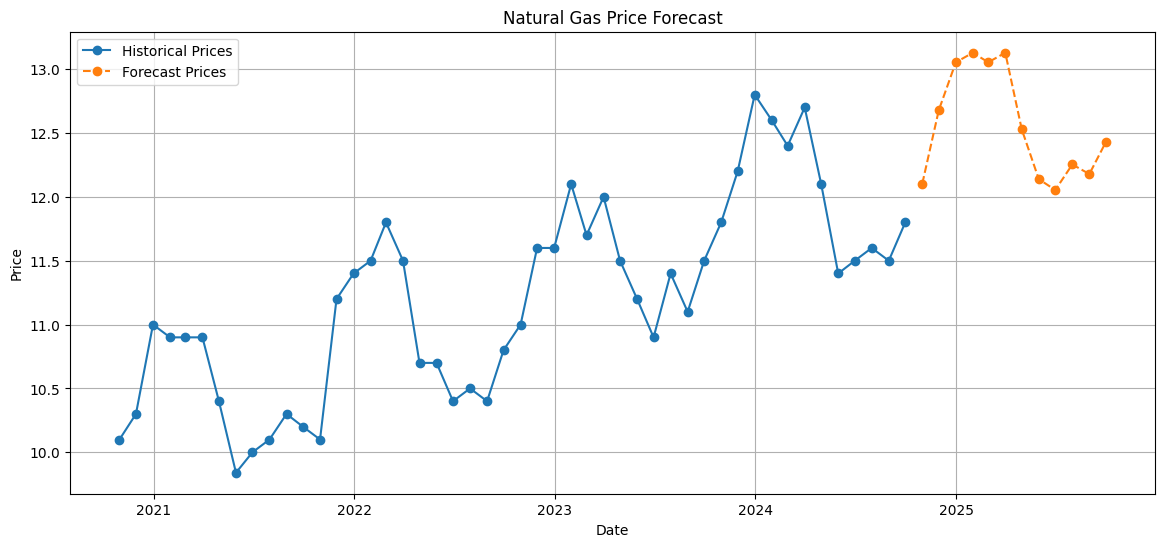

In [25]:
plt.figure(figsize=(14,6))

# Historical prices
plt.plot(df['Date'], df['Price'], label='Historical Prices', marker='o')

# Forecast prices
plt.plot(future_df['Date'], future_df['Price'],
         label='Forecast Prices',
         linestyle='--',
         marker='o')

plt.title('Natural Gas Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

## Create a Price Estimation Function

We now create a function that:

- Takes any date as input.
- Returns estimated gas price.
- Uses interpolation for dates between known observations.
- Uses forecasted values for future dates.

In [27]:
from scipy.interpolate import interp1d

In [28]:
combined_df['NumericDate'] = combined_df['Date'].map(pd.Timestamp.toordinal)

# Create interpolation function
price_function = interp1d(
    combined_df['NumericDate'],
    combined_df['Price'],
    kind='linear',
    fill_value='extrapolate'
)

In [29]:
def estimate_gas_price(input_date):
    """
    Estimate natural gas price for any date.

    Parameters:
    input_date (str): Date in YYYY-MM-DD format

    Returns:
    float: Estimated gas price
    """

    input_date = pd.to_datetime(input_date)
    numeric_date = input_date.toordinal()

    estimated_price = price_function(numeric_date)

    return round(float(estimated_price), 2)

In [30]:
print(estimate_gas_price('2023-05-15'))
print(estimate_gas_price('2025-06-30'))
print(estimate_gas_price('2025-12-31'))

11.35
12.05
13.2


Interpolation

Used for estimating prices between known monthly observations.

Example:

- If prices are known for Jan 31 and Feb 28,
- Interpolation estimates prices for dates like Feb 10.
- Exponential Smoothing

Used for forecasting future prices because:

- Captures trend
- Captures seasonality
- Works well for monthly business data

# Business Value

This solution helps financial institutions and energy trading firms:

- Estimate storage contract values
- Predict future energy costs
- Analyze seasonal demand patterns
- Support trading and hedging decisions

## Final Conclusion

The natural gas market demonstrates:

- Strong seasonal behavior
- Long-term upward trends
- Cyclical fluctuations driven by demand and supply dynamics

Using Holt-Winters Exponential Smoothing with interpolation provides a practical and reliable method for:

- Historical price estimation
- Future price forecasting
- Long-term contract valuation

This solution can easily be extended with:

- ARIMA/SARIMA models
- Machine learning models
- Weather and macroeconomic data
- Real-time market feeds